## Regression problems with Tensorflow

In [1]:
# pip install tensorflow

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt




In [3]:
X = np.array([-7, -6, -4, -1, 2.0, 5.0, 9.0, 11.00, 14.0, 15.0, 18])
y = np.arange(0, 33, 3)
print(len(X))
print(len(y))


11
11


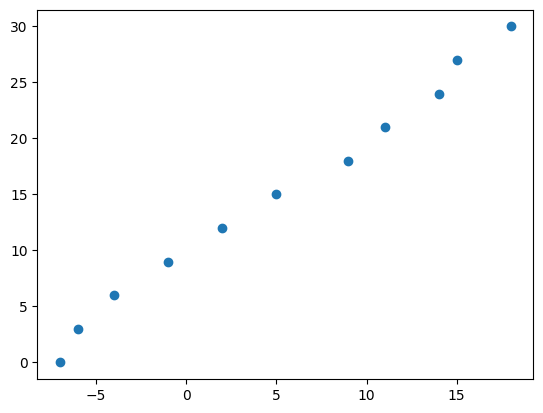

In [4]:
plt.scatter(X, y)
plt.show()

In [5]:
# Creating a demo tensor
X_tensor = tf.constant(X)
y_tensor = tf.constant(y)

## Steps to compile a Tensorflow Model

1. **Create the model** - define the input, hidden and output layers. 
2. **Compile the model** - define the loss function, the optimizer and the evaluation metrics
3. **Fit the model**

In [7]:
# Set seed
tf.random.set_seed(42)

# 1. Create a model using the Sequential api

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name="first_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_1")

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
            optimizer=tf.keras.optimizers.SGD(),
            metrics=["mae"])



c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ first_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

* Total params -  total number of parameters in the model.
* Trainable parameters - these are the parameters the model can update
* Non-trainable - parameters that are not updated during training (read: Transfer Learning)


In [9]:
X_train = X_tensor[:8]
y_train = y_tensor[:8]
y_train

<tf.Tensor: shape=(8,), dtype=int64, numpy=array([ 0,  3,  6,  9, 12, 15, 18, 21])>

In [10]:
model.fit(X_train, y_train, epochs=100, verbose=2)

Epoch 1/100
1/1 - 2s - 2s/step - loss: 14.6838 - mae: 14.6838
Epoch 2/100
1/1 - 0s - 102ms/step - loss: 14.0729 - mae: 14.0729
Epoch 3/100
1/1 - 0s - 160ms/step - loss: 13.4979 - mae: 13.4979
Epoch 4/100
1/1 - 0s - 177ms/step - loss: 12.9542 - mae: 12.9542
Epoch 5/100
1/1 - 0s - 98ms/step - loss: 12.4376 - mae: 12.4376
Epoch 6/100
1/1 - 0s - 100ms/step - loss: 11.9438 - mae: 11.9438
Epoch 7/100
1/1 - 0s - 101ms/step - loss: 11.5934 - mae: 11.5934
Epoch 8/100
1/1 - 0s - 118ms/step - loss: 11.3823 - mae: 11.3823
Epoch 9/100
1/1 - 0s - 184ms/step - loss: 11.1747 - mae: 11.1747
Epoch 10/100
1/1 - 0s - 177ms/step - loss: 10.9700 - mae: 10.9700
Epoch 11/100
1/1 - 0s - 181ms/step - loss: 10.7675 - mae: 10.7675
Epoch 12/100
1/1 - 0s - 329ms/step - loss: 10.5664 - mae: 10.5664
Epoch 13/100
1/1 - 0s - 200ms/step - loss: 10.3661 - mae: 10.3661
Epoch 14/100
1/1 - 0s - 177ms/step - loss: 10.2094 - mae: 10.2094
Epoch 15/100
1/1 - 0s - 196ms/step - loss: 10.1539 - mae: 10.1539
Epoch 16/100
1/1 - 0s -

In [11]:
# Get summary of our model
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ first_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [12]:
# pip install pydot

In [13]:
from tensorflow.keras.utils import plot_model

plot_model(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [ ]:
# pip install graphviz

In [14]:
X_test = X_tensor[9:11]
y_test = y_tensor[9:11]
y_train

<tf.Tensor: shape=(8,), dtype=int64, numpy=array([ 0,  3,  6,  9, 12, 15, 18, 21])>

In [15]:
y_preds = model.predict(X_test)
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step


array([[26.19824],
       [30.66831]], dtype=float32)

In [16]:
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_preds):
    """
    plots the training data, testing and ground truth
    
    """
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", label="Training Data")
    plt.scatter(test_data, test_labels, c="g", label="Testing Data")
    plt.scatter(test_data, predictions, c='r', label="Predictions")
    plt.legend()
    plt.show()

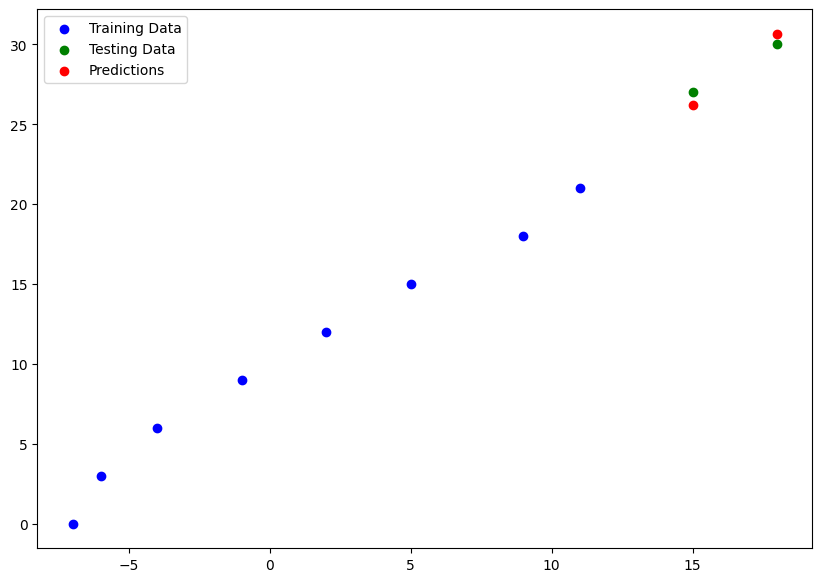

In [17]:
plot_predictions()

**Evaluating our model with regression matrix**

1. *MAE -  Mean Absolute Error*
2. *MSE - Mean Squared Error*

In [18]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step - loss: 0.7350 - mae: 0.7350


[0.7350349426269531, 0.7350349426269531]

In [34]:
mae = tf.metrics.mae(y_test, y_preds)
mae

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([0.8017597 , 0.66831017], dtype=float32)>